In [4]:
import pandas
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.pipeline import Pipeline  
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

In [5]:
BLACK = '\033[30m'
RED = '\033[31m'
GREEN = '\033[32m'
YELLOW = '\033[33m'
BLUE = '\033[34m'
MAGENTA = '\033[35m'
CYAN = '\033[36m'
LIGHT_GRAY = '\033[37m'
DARK_GRAY = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
RESET = '\033[0m'

def colored_text(color, txt):
    return color + str(txt) + RESET

In [6]:
# Loading tables of this category across all years
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_usagers = []

for year in years:
    df_usagers_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"usagers-{year}.csv"), encoding="utf-8", sep = ";")
    df_usagers.append(df_usagers_year)

df_usagers = pandas.concat(df_usagers)
df_usagers

,Num_Acc,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp,id_usager
0,201900000001,138 306 524,B01,2,2,4,2,2002.0,0,1,0,-1,-1,-1,-1,NaN
1,201900000001,138 306 524,B01,1,1,4,2,1993.0,5,1,0,-1,-1,-1,-1,NaN
2,201900000001,138 306 525,A01,1,1,1,1,1959.0,0,1,0,-1,-1,-1,-1,NaN
3,201900000002,138 306 523,A01,1,1,4,2,1994.0,0,1,0,-1,-1,-1,-1,NaN
4,201900000003,138 306 520,A01,1,1,1,1,1996.0,0,1,0,-1,-1,0,-1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125182,202400054401,155 686 119,Y01,1,1,4,2,1978.0,0,0,0,0,-1,-1,-1,203 859 570
125183,202400054401,155 686 120,A01,1,1,1,1,1984.0,0,2,6,0,-1,-1,-1,203 859 572
125184,202400054402,155 686 118,A01,1,1,4,1,1981.0,4,1,0,-1,-1,-1,-1,203 859 569
125185,202400054402,155 686 121,B01,1,1,4,2,1986.0,9,1,0,-1,-1,-1,-1,203 859 571


In [7]:
# These features we are not going to use as we don't need to uniquely 
# identify a person and we have id_vehicule to link this table to the others
df_usagers.drop(columns=["num_veh", "id_usager"] ,inplace=True)

In [8]:
# Correcting typo errors and converting to right type
df_usagers["id_vehicule"] = (
    df_usagers["id_vehicule"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)  # keeping only digits
    .astype("int64")
)

In [9]:
# Other attributes to correct errors and convert to int
column_names_to_int = ["place", "catu", "grav", "sexe", "an_nais", "trajet", "secu1", "secu2", "secu3", "locp", "actp", "etatp"]

df_usagers[column_names_to_int] = df_usagers[column_names_to_int].apply(
    lambda col: pandas.to_numeric(
        col.astype(str).str.extract(r'(-?\d+)')[0],
        errors="coerce"
    ),
    axis=0 # for each column
)
df_usagers.info()

<class 'pandas.DataFrame'>
Index: 745158 entries, 0 to 125186
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Num_Acc      745158 non-null  int64  
 1   id_vehicule  745158 non-null  int64  
 2   place        745158 non-null  int64  
 3   catu         745158 non-null  int64  
 4   grav         745158 non-null  int64  
 5   sexe         745158 non-null  int64  
 6   an_nais      734040 non-null  float64
 7   trajet       745158 non-null  int64  
 8   secu1        745158 non-null  int64  
 9   secu2        745158 non-null  int64  
 10  secu3        745158 non-null  int64  
 11  locp         745158 non-null  int64  
 12  actp         742496 non-null  float64
 13  etatp        745158 non-null  int64  
dtypes: float64(2), int64(12)
memory usage: 85.3 MB


In [10]:
# Checking for duplicates
df_usagers.duplicated().sum()

np.int64(739)

In [11]:
df_usagers = df_usagers.drop_duplicates()

In [12]:
# Next we are going to see the missing values proportion across different features
df_usagers.replace(-1, pandas.NA, inplace=True)
df_usagers["trajet"] = df_usagers["trajet"].replace(0, pandas.NA) # For trajet -1 and 0 mean missing value

for col in df_usagers.columns:
    prop = df_usagers[col].isna().sum() / df_usagers.shape[0]
    print(f"For {colored_text(MAGENTA, col)} proportion missing: {prop * 100:.2f}%")

For Num_Acc proportion missing: 0.00%
For id_vehicule proportion missing: 0.00%
For place proportion missing: 0.00%
For catu proportion missing: 0.00%
For grav proportion missing: 0.06%
For sexe proportion missing: 1.43%
For an_nais proportion missing: 1.49%
For trajet proportion missing: 27.77%
For secu1 proportion missing: 1.34%
For secu2 proportion missing: 40.59%
For secu3 proportion missing: 97.31%
For locp proportion missing: 45.91%
For actp proportion missing: 42.07%
For etatp proportion missing: 92.19%


In [13]:
# we can notice that for trajet we have many missing data, but before removing this column, 
# we want to keep this feature to see if it can help us in our target prediction, so let's replace missing values with 0 for now
# we are going to check its importance later in the correlation matrix
df_usagers["trajet"] = df_usagers["trajet"].replace(pandas.NA, 0)

In [14]:
# we are dropping rows were our target is missing
df_usagers = df_usagers.dropna(subset=["grav"])

In [15]:
# Next, there are features that we definitely want to keep ("sexe", "an_nais", "place", "catu"),
# but let's first check the target label distribution in the rows where at least one of these values is missing:
usagers_prop = df_usagers[["sexe", "an_nais", "place", "catu", "grav"]].copy()

invalid_rows = usagers_prop[usagers_prop[["sexe", "an_nais", "place", "catu"]].isna().any(axis=1)]

print("Proportion of the target labels in the rows to be removed:")
print(invalid_rows['grav'].value_counts(normalize=True))
print()
print("Proportion of the target labels in the entire dataset:")
print(usagers_prop['grav'].value_counts(normalize=True))

Proportion of the target labels in the rows to be removed:
grav
1    0.999160
4    0.000746
3    0.000093
Name: proportion, dtype: float64

Proportion of the target labels in the entire dataset:
grav
1    0.421022
4    0.398566
3    0.153700
2    0.026712
Name: proportion, dtype: float64


In [16]:
# As we can see, the distribution of the target labels is not very different:
# the main categories are still 1 and 4, followed by 3
# Thus, removing these rows should not significantly affect the overall distribution
# Also as it can be hard and complicated to impute, we choose to remove the rows where these values are missing
# We also can check that the proportion of removed rows is not too large:
before = len(df_usagers)
df_usagers = df_usagers.dropna(subset=["grav", "sexe", "an_nais", "place", "catu"])
after = len(df_usagers)

print(f"Removed {before-after} rows ({(before-after)/before*100:.2f}%)")

Removed 10720 rows (1.44%)


As for secu1, secu2 and secu3 these are important but we have ot convert these into more meaningfull and usable form.

For this, let's see their distribution and how they relate to gravity

In [17]:
equipments = {
    0: "aucun",
    1: "ceinture",
    2: "casque",
    3: "dispositif_enfant",
    4: "gilet_reflechissant",
    5: "airbag",
    6: "gants",
    7: "gants_airbag",
    8: "non determinable",
    9: "autre"
}

# function to pass from secu1, secu2, secu3 to one hot-encoding with some changes specific to our dataset
def encode_secu(df):
    # Initialize columns EXCEPT gants_airbag, because 
    # it means gants and airbag so just converting into these 2 categories
    for name in equipments.values():
        if name != "gants_airbag":
            df[name] = 0

    for col in ["secu1", "secu2", "secu3"]:
        for code, name in equipments.items():
            if name == "gants_airbag":
                df.loc[df[col] == code, "gants"] = 1
                df.loc[df[col] == code, "airbag"] = 1
            else:
                df.loc[df[col] == code, name] = 1

    # if any equipment used, we set aucun = 0
    protection_cols = [c for c in equipments.values() if c not in ["aucun", "gants_airbag"]]
    df.loc[df[protection_cols].sum(axis=1) > 0, "aucun"] = 0

    return df

# applying the function and deleting the columns
df_usagers = encode_secu(df_usagers)    
df_usagers.drop(columns=["secu1", "secu2", "secu3"] ,inplace=True)

In [18]:
# As protection is a quite important attribute, we though to see how having no protection 
# can affect severity of and accident, excluding pedestrians, as they don't have protection is any case.
df_no_protection = df_usagers[
    (df_usagers["aucun"] == 1) &
    (df_usagers["catu"] != 3)
] # without pedestrians

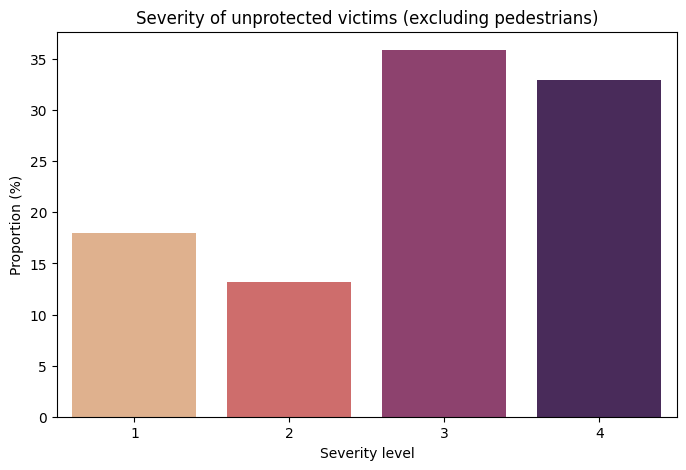

In [19]:
# After plotting, we can clearly obesrve a bigger proportion in severe accidents
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_no_protection,
    x="grav",
    hue="grav",
    stat="percent",
    palette="flare",
    legend=False
)

plt.title("Severity of unprotected victims (excluding pedestrians)")
plt.xlabel("Severity level")
plt.ylabel("Proportion (%)")
plt.show()

In [20]:
# next, we convert the year of birth into age
# df_usagers["Num_Acc"][:4] -> contains year
df_usagers["year_acc"] = df_usagers["Num_Acc"].astype(str).str[:4]
df_usagers["year_acc"] = pandas.to_numeric(df_usagers["year_acc"], errors="coerce")

df_usagers["age"] = df_usagers["year_acc"] - df_usagers["an_nais"]
df_usagers.drop(columns=["an_nais", "year_acc"], inplace=True)

In [21]:
# seeing the distribution
df_usagers["age"].describe()

count    733280.000000
mean         38.604653
std          19.014005
min           0.000000
25%          23.000000
50%          35.000000
75%          52.000000
max         120.000000
Name: age, dtype: float64

In [22]:
len(df_usagers[df_usagers["age"] > 100])

221

In [23]:
df_usagers[df_usagers["age"] > 100]["age"].value_counts().sort_index()

age
101.0      9
102.0      5
103.0      1
104.0      1
106.0      1
108.0      1
109.0      7
110.0      5
118.0     43
119.0    133
120.0     15
Name: count, dtype: int64

In [24]:
# deleting strange ages
df_usagers = df_usagers[df_usagers["age"] <= 100]

<Axes: xlabel='age', ylabel='Count'>

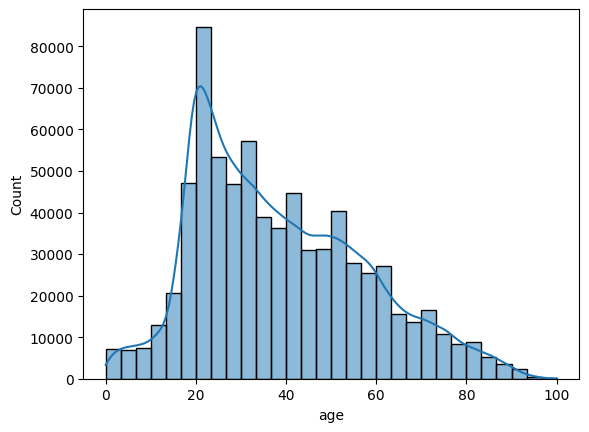

In [25]:
# distribution of age feature after removing (looks legitimate)
sns.histplot(df_usagers["age"], bins=30, kde=True) 

In [26]:
# specifically for pedestrians, the feature "place" (=10 for pedestrians) should be the same as "catu" (=3 for pedestrians)
# so we need to check whetether there are mistakes and drop rows when information differ, 
# as it is contradiction and we have no way to obtain the real category
incoherences = df_usagers[
    ((df_usagers["place"] == 10) & (df_usagers["catu"] != 3)) |
    ((df_usagers["catu"] == 3) & (df_usagers["place"] != 10))
]

print("Number of inconsistent examples : ",  len(incoherences))

# Nothing to correct here

Number of inconsistent examples :  0


In [27]:
# we have decided to do binary classification, so we design our target
df_usagers["grav_bin"] = df_usagers["grav"].replace({
    1: 0,  # Unharmed -> not severe
    4: 0,  # Minor injury -> not severe
    2: 1,  # Killed -> severe
    3: 1   # Hospitalized injury -> severe
})

In [28]:
# Prinitng the proportion of target labels in our dataset
mapping = {
    0: "Not severly injured",
    1: "Severly injured"
}

counts = df_usagers["grav_bin"].value_counts()
counts.index = counts.index.map(mapping)

for cl, prop in counts.items():
    print(f"For {colored_text(MAGENTA, cl)} proportion: {prop / len(df_usagers) * 100:.2f}%")

For Not severly injured proportion: 81.69%
For Severly injured proportion: 18.31%


In [29]:
# We can also take a look at more specific target lables
mapping = {
    1: "Unharmed",
    2: "Killed",
    3: "Hospitalized injury",
    4: "Minor injury"
}

counts = df_usagers["grav"].value_counts()
counts.index = counts.index.map(mapping)

for cl, prop in counts.items():
    print(f"For {colored_text(MAGENTA, cl)} proportion: {prop / len(df_usagers) * 100:.2f}%")

For Unharmed proportion: 41.25%
For Minor injury proportion: 40.44%
For Hospitalized injury proportion: 15.60%
For Killed proportion: 2.71%


In [30]:
# as we have converted empty values into 
cols_int = ["place", "catu", "sexe", "age", "aucun", "ceinture", "casque", "dispositif_enfant", "gilet_reflechissant", "airbag", "non determinable", "gants", "autre", "grav_bin", "grav"]
df_usagers[cols_int] = df_usagers[cols_int].astype("int64")

In [31]:
# Defining all features that are going to be used
features = ['place', 'catu', 'sexe', 'age', 
       'aucun', 'ceinture', 'casque', 'dispositif_enfant',
       'gilet_reflechissant', 'airbag', 'gants', 'autre', "non determinable"]

# We need to separate by category as the preprocessing will differ
binary_features = ['aucun', 'ceinture', 'casque', 'dispositif_enfant', 'gilet_reflechissant', 'airbag', 'gants', 'autre', "non determinable"]
numerical_features = ["age"]
categorical_features = list(set(features) - set(binary_features) - set(numerical_features))

target = 'grav_bin'

In [32]:
# Let's do analysis of our features distribution and see the proportion in each of target labels

# to simplify the visualisation let's replace numeric categories with strings
df_usagers_analyse = df_usagers.copy()

mapping = {
    0: "Absent",
    1: "Present"
}
pres_abs_features = [
    'aucun', 'ceinture', 'casque', 'dispositif_enfant',
    'gilet_reflechissant', 'airbag', 'gants', 'autre', "non determinable"
]
df_usagers_analyse[pres_abs_features] = df_usagers_analyse[pres_abs_features].replace(mapping)

mapping = {
    1: "Driver",
    2: "Front right passenger",
    3: "Rear right passenger",
    4: "Rear left passenger",
    5: "Front left passenger",
    6: "Other seat in light vehicle",
    7: "Public transport – seated",
    8: "Public transport – standing",
    9: "Other public transport",
    10: "Pedestrian (not applicable)"
}

df_usagers_analyse["place"] = df_usagers_analyse["place"].replace(mapping)

mapping = {
    1: "Driver",
    2: "Passenger",
    3: "Pedestrian"
}
df_usagers_analyse["catu"] = df_usagers_analyse["catu"].replace(mapping)

mapping = {
    1: "Male",
    2: "Female"
}
df_usagers_analyse["sexe"] = df_usagers_analyse["sexe"].replace(mapping)

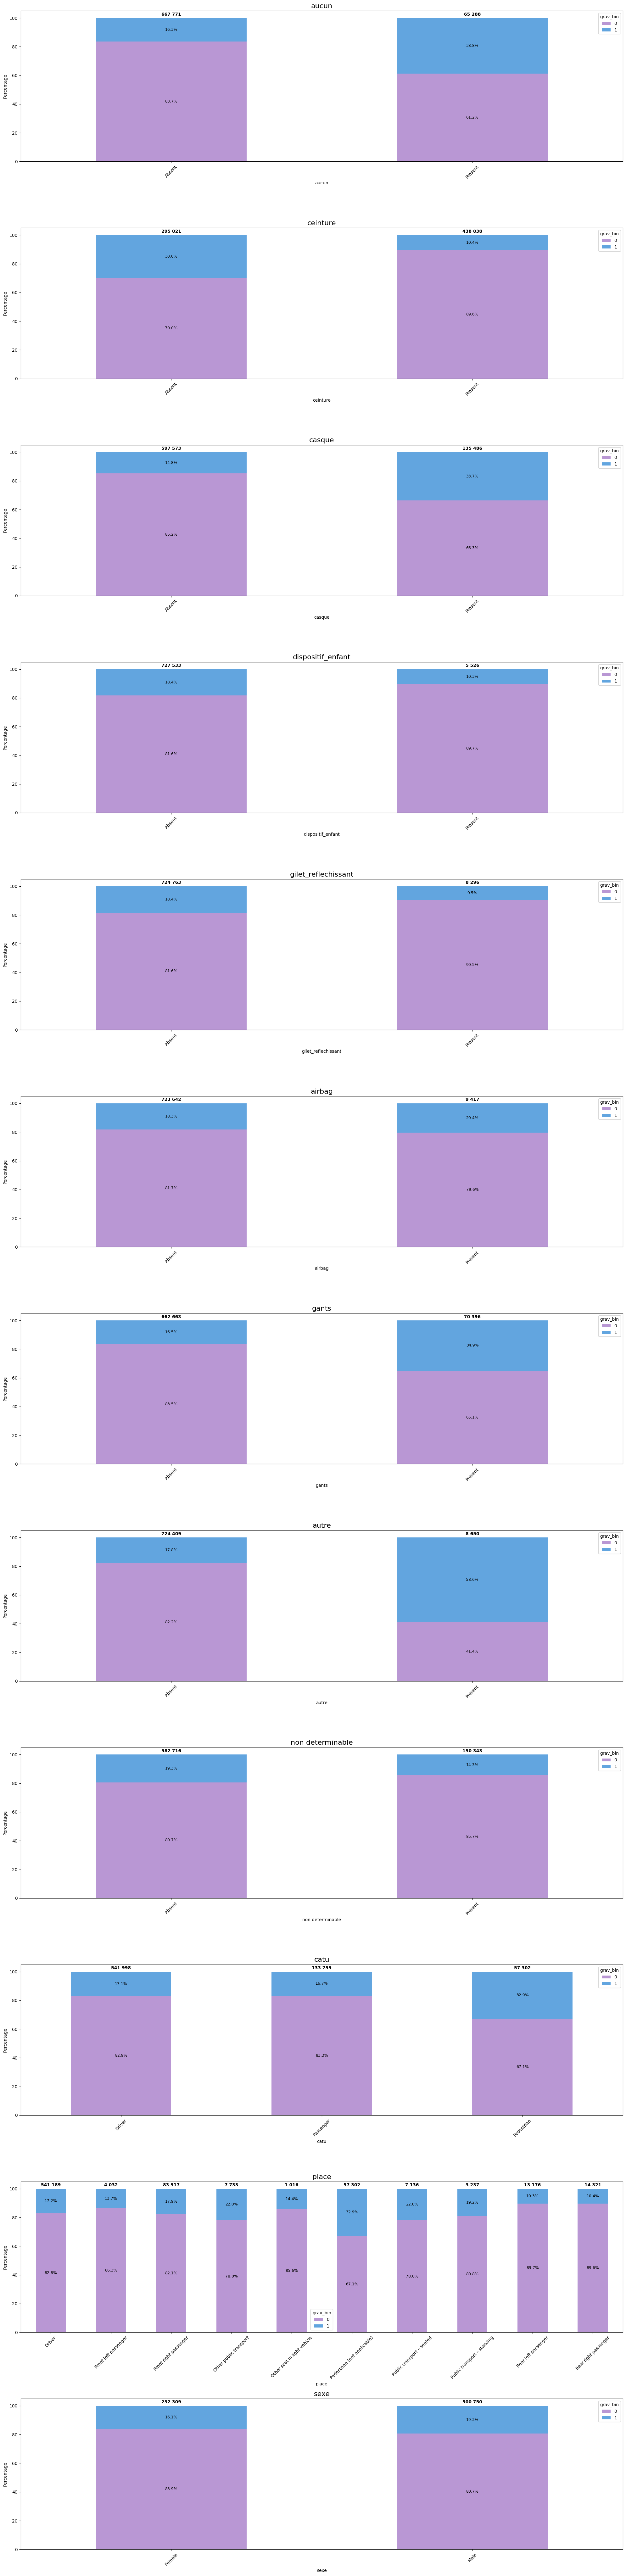

In [33]:
features_to_analyse = binary_features + categorical_features

fig, ax = plt.subplots(len(features_to_analyse), 1, figsize=(20, 6*len(features_to_analyse) + 10))

df_usagers_analyse = df_usagers_analyse.reset_index(drop=True)

for i, feature in enumerate(features_to_analyse):
    ct = pandas.crosstab(
        df_usagers_analyse[feature],
        df_usagers_analyse[target],
        normalize="index"
    ) * 100

    counts = df_usagers_analyse[feature].value_counts().sort_index()

    # Plot
    ct.plot(kind="bar", stacked=True, ax=ax[i], color=["#B997D4", "#62A5DF"])

    # Add % labels inside bars
    for j, category in enumerate(ct.index):
        cumulative = 0
        for k, col in enumerate(ct.columns):
            value = ct.loc[category, col]
            if value > 3:  # avoid clutter for tiny values
                ax[i].text(
                    j,
                    cumulative + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += value

    # Add total count above bars
    for j, category in enumerate(ct.index):
        ax[i].text(
            j,
            101,
            f"{counts[category]:,}".replace(",", " "),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Percentage")

plt.tight_layout()

In [34]:
def latex_escape_category(x):
    x = str(x)

    x = x.replace("<=", r"$\le$")
    x = x.replace(">=", r"$\ge$")
    x = x.replace("<", r"$<$")
    x = x.replace(">", r"$>$")

    x = x.replace("&", r"\&")
    x = x.replace("%", r"\%")
    x = x.replace("_", r"\_")
    x = x.replace("#", r"\#")

    return x

output_lines = []

for feature in features_to_analyse:
    counts = df_usagers_analyse.groupby(feature)[target].value_counts().unstack(fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0) * 100

    for i, category in enumerate(counts.index):
        category_latex = latex_escape_category(category)
        count = counts.loc[category].sum()
        not_severe = proportions.loc[category].get(0, 0)
        severe = proportions.loc[category].get(1, 0)

        if i == 0:
            line = f"\\texttt{{{feature}}} & {category} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"
        else:
            line = f" & {category} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"

        line = line.replace(",", " ")

        output_lines.append(line)

    output_lines.append("\\hline")

print("\n".join(output_lines))

\texttt{aucun} & Absent & 667 771 & 83.7 & 16.3 \\
 & Present & 65 288 & 61.2 & 38.8 \\
\hline
\texttt{ceinture} & Absent & 295 021 & 70.0 & 30.0 \\
 & Present & 438 038 & 89.6 & 10.4 \\
\hline
\texttt{casque} & Absent & 597 573 & 85.2 & 14.8 \\
 & Present & 135 486 & 66.3 & 33.7 \\
\hline
\texttt{dispositif_enfant} & Absent & 727 533 & 81.6 & 18.4 \\
 & Present & 5 526 & 89.7 & 10.3 \\
\hline
\texttt{gilet_reflechissant} & Absent & 724 763 & 81.6 & 18.4 \\
 & Present & 8 296 & 90.5 & 9.5 \\
\hline
\texttt{airbag} & Absent & 723 642 & 81.7 & 18.3 \\
 & Present & 9 417 & 79.6 & 20.4 \\
\hline
\texttt{gants} & Absent & 662 663 & 83.5 & 16.5 \\
 & Present & 70 396 & 65.1 & 34.9 \\
\hline
\texttt{autre} & Absent & 724 409 & 82.2 & 17.8 \\
 & Present & 8 650 & 41.4 & 58.6 \\
\hline
\texttt{non determinable} & Absent & 582 716 & 80.7 & 19.3 \\
 & Present & 150 343 & 85.7 & 14.3 \\
\hline
\texttt{catu} & Driver & 541 998 & 82.9 & 17.1 \\
 & Passenger & 133 759 & 83.3 & 16.7 \\
 & Pedestrian &

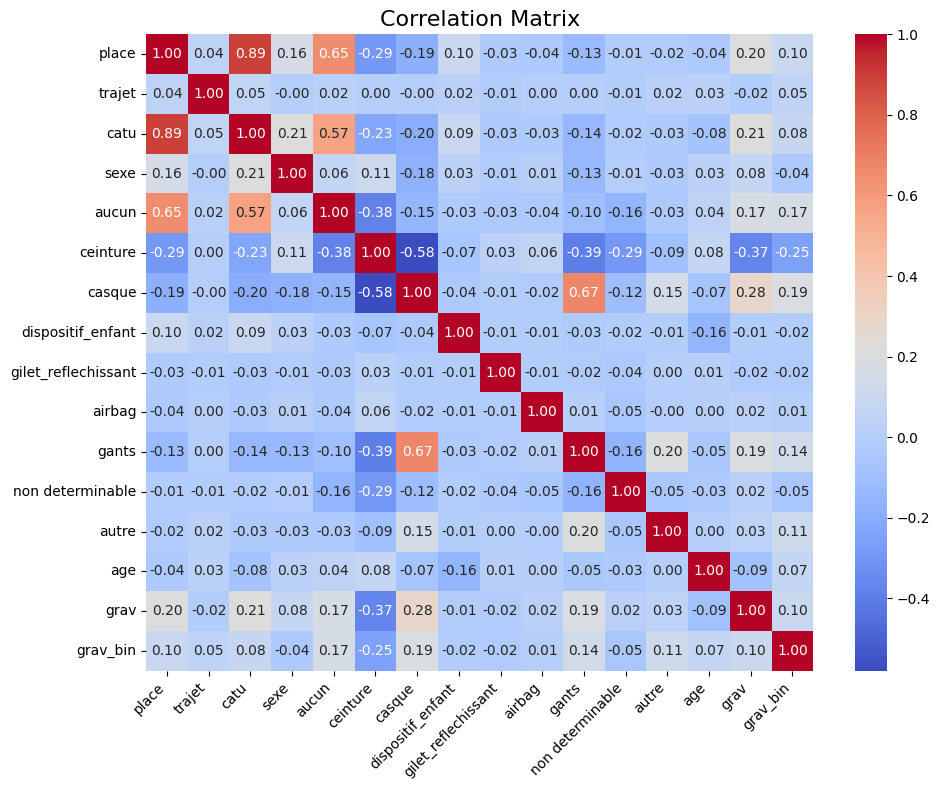

In [35]:
# Let's see the correlations between features
plt.figure(figsize=(10, 8))

sns.heatmap(
    df_usagers[['place', 'trajet', 'catu', 'sexe', 'aucun', 'ceinture', 'casque',
       'dispositif_enfant', 'gilet_reflechissant', 'airbag', 'gants', 'non determinable',
       'autre', 'age', 'grav', 'grav_bin']].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [37]:
# let's see how at this stage we can predict our target label
# first we are splitting the dataset on test and train
X = df_usagers[features]
y = df_usagers[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)

In [ ]:
# defining preprocessing depending on the type of the feature
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features),
        ("bin", "passthrough", binary_features)
    ]
)

# our ML models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=20),
    "Decision Tree": DecisionTreeClassifier(random_state=20),
    "Gradient Boosting": GradientBoostingClassifier(random_state=20)
}

# we are going to test with oversampling and undersampling
pipelines_over = {}
pipelines_under = {}
for name, model in models.items():
    pipelines_over[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("sampling", RandomOverSampler(random_state=20)),
        ("model", model)
    ])
    pipelines_under[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("sampling", RandomUnderSampler(random_state=20)),
        ("model", model)
    ])

# First we are doing cross-validation of our models with oversampling
print(colored_text(BRIGHT_BLUE, "Model selection with cross-validation (oversampling)"))
for name, pipe in pipelines_over.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=20))
    print("\n", name)
    print(classification_report(y_train, y_pred))

# Then we are doing cross-validation of our models with undersampling
print(colored_text(BRIGHT_BLUE, "Model selection with cross-validation (undersampling)"))
for name, pipe in pipelines_under.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=20))
    print("\n", name)
    print(classification_report(y_train, y_pred))

Model selection with cross-validation (oversampling)

 Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.72      0.80    479081
           1       0.33      0.61      0.43    107366

    accuracy                           0.70    586447
   macro avg       0.61      0.67      0.61    586447
weighted avg       0.79      0.70      0.73    586447


 Decision Tree
              precision    recall  f1-score   support

           0       0.90      0.71      0.79    479081
           1       0.33      0.63      0.43    107366

    accuracy                           0.69    586447
   macro avg       0.61      0.67      0.61    586447
weighted avg       0.79      0.69      0.72    586447


 Gradient Boosting
              precision    recall  f1-score   support

           0       0.90      0.71      0.79    479081
           1       0.33      0.65      0.44    107366

    accuracy                           0.70    586447
   macro avg     

              precision    recall  f1-score   support

           0       0.90      0.71      0.79    119770
           1       0.33      0.64      0.44     26842

    accuracy                           0.69    146612
   macro avg       0.61      0.67      0.61    146612
weighted avg       0.79      0.69      0.73    146612



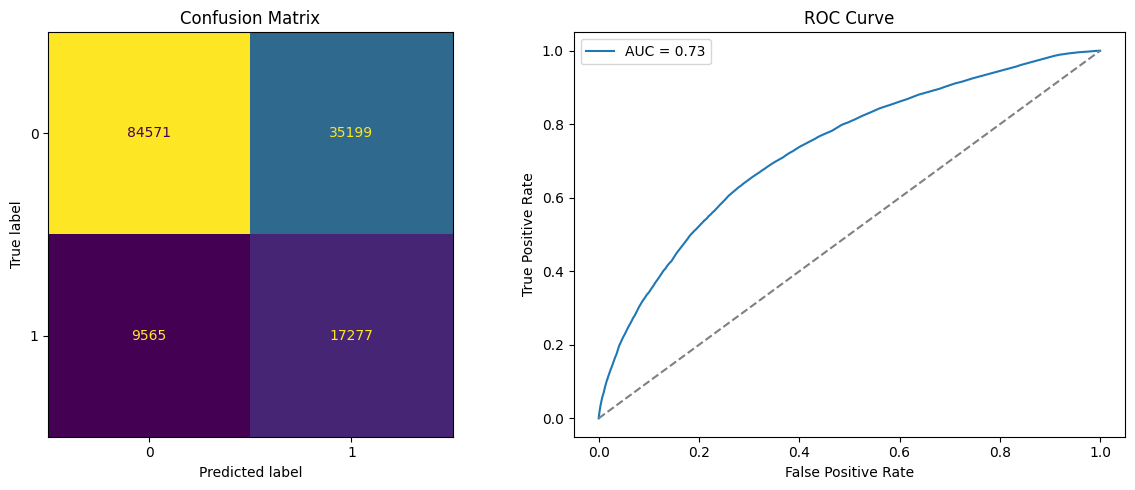

In [ ]:
# Finally, we are going to take the best model among the previously trained and select the best one according to f1 score 
# and test it on the test set
# according to the previous prints the models perform approximatively on the same level, so we can take for example 
# Gradient boosting with oversampling which shows slighlty better results for class 1 (severe)

# Train and predict
model = pipelines_over["Gradient Boosting"]
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

Furthermore, we also wanted to take a look at a particular category: pedestrians.

In [38]:
# We are filtering only pedestrians in our dataset
df_pedestrians = df_usagers[df_usagers["catu"] == 3]

In [39]:
# we are definifn specific set of features for pedestrians
features_pedestrians = ['sexe', 'locp', 'actp', 'etatp', 'age',"aucun", "gilet_reflechissant", 'autre', 'non determinable']
target = "grav_bin"

# and dropping rows when these features are empty
df_pedestrians_n = df_pedestrians.dropna(subset=features_pedestrians)

In [40]:
print(f"Proportion of pedestrians taken after removing lines with missing values: {len(df_pedestrians_n) / len(df_pedestrians)*100:.3f} %")
print(f"Final number of examples: {len(df_pedestrians_n)}")

Proportion of pedestrians taken after removing lines with missing values: 94.375 %
Final number of examples: 54079


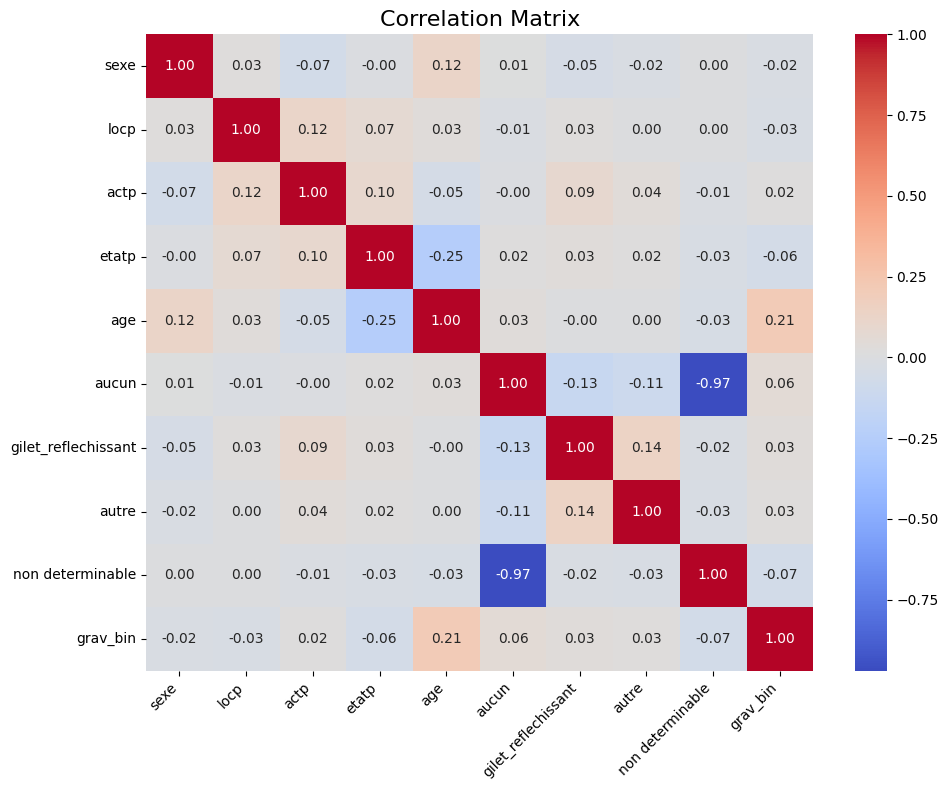

In [42]:
# Let's see the correlations between features
plt.figure(figsize=(10, 8))

sns.heatmap(
    df_pedestrians_n[features_pedestrians + [target]].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Prinitng the proportion of target labels in our pedestrians dataset
mapping = {
    0: "Not severly injured",
    1: "Severly injured"
}

counts = df_pedestrians_n["grav_bin"].value_counts()
counts.index = counts.index.map(mapping)

for cl, prop in counts.items():
    print(f"For {colored_text(MAGENTA, cl)} proportion: {prop / len(df_pedestrians_n) * 100:.2f}%")

For Not severly injured proportion: 67.37%
For Severly injured proportion: 32.63%


In [ ]:
# seeing what methods of security are present in how many rows (these are the only binary features)
df_pedestrians_n[binary_features].sum()

aucun                  42957
ceinture                   0
casque                     0
dispositif_enfant          0
gilet_reflechissant      250
airbag                     0
gants                      0
autre                    155
non determinable       10606
dtype: int64

In [ ]:
# sorting features by category
numerical_features = ["age"]
binary_features = ["aucun", "gilet_reflechissant", 'autre', 'non determinable']
categorical_features = list(set(features_pedestrians) - set(numerical_features) - set(binary_features))


In [ ]:
# splitting the set into training and testing
X = df_pedestrians_n[features_pedestrians]
y = df_pedestrians_n[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features),
        ("bin", "passthrough", binary_features)
    ]
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=20),
    "Decision Tree": DecisionTreeClassifier(random_state=20),
    "Gradient Boosting": GradientBoostingClassifier(random_state=20)
}

# we are going to test with oversampling and undersampling
pipelines_over = {}
pipelines_under = {}
for name, model in models.items():
    pipelines_over[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("sampling", RandomOverSampler(random_state=20)),
        ("model", model)
    ])
    pipelines_under[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("sampling", RandomUnderSampler(random_state=20)),
        ("model", model)
    ])

# First we are doing cross-validation of our models with oversampling
print(colored_text(BRIGHT_BLUE, "Model selection with cross-validation (oversampling)"))
for name, pipe in pipelines_over.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=20))
    print("\n", name)
    print(classification_report(y_train, y_pred))

# Then we are doing cross-validation of our models with undersampling
print(colored_text(BRIGHT_BLUE, "Model selection with cross-validation (undersampling)"))
for name, pipe in pipelines_under.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=20))
    print("\n", name)
    print(classification_report(y_train, y_pred))

Model selection with cross-validation (oversampling)

 Logistic Regression
              precision    recall  f1-score   support

           0       0.78      0.62      0.69     29148
           1       0.45      0.64      0.53     14115

    accuracy                           0.63     43263
   macro avg       0.61      0.63      0.61     43263
weighted avg       0.67      0.63      0.64     43263


 Decision Tree
              precision    recall  f1-score   support

           0       0.74      0.67      0.70     29148
           1       0.43      0.50      0.46     14115

    accuracy                           0.62     43263
   macro avg       0.58      0.59      0.58     43263
weighted avg       0.64      0.62      0.62     43263


 Gradient Boosting
              precision    recall  f1-score   support

           0       0.77      0.68      0.73     29148
           1       0.47      0.59      0.53     14115

    accuracy                           0.65     43263
   macro avg     

              precision    recall  f1-score   support

           0       0.78      0.68      0.72      7287
           1       0.47      0.60      0.53      3529

    accuracy                           0.65     10816
   macro avg       0.62      0.64      0.63     10816
weighted avg       0.68      0.65      0.66     10816



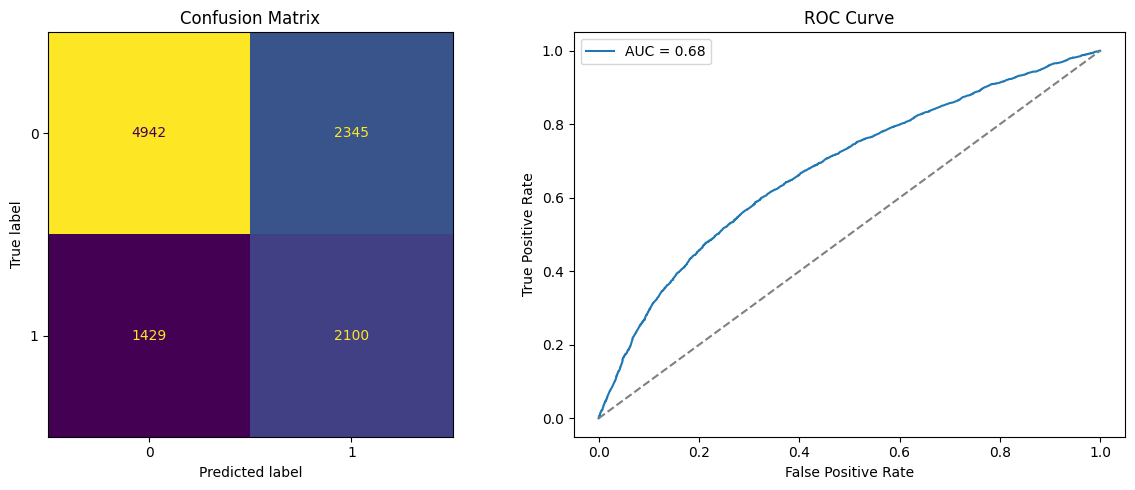

In [ ]:
# Here also, we are going to take the best model among the previously trained and select the best one according to f1 score 
# and test it on the test set
# according to the previous prints the models perform approximatively on the same level, so we can take for example 
# Gradient boosting with oversimpling which shows slighlty better results for class 1 (severe)

# Train and predict
model = pipelines_over["Gradient Boosting"]
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Finally we are going to save the dataset cleaned
df_usagers.to_csv("data_clean/df_usagers_clean.csv", index=False)